# Train Crack Detection Model
Training MobileNetV2 on 40K images (20K damage + 20K no-damage)

In [24]:
import os
import shutil
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.21.0
GPU Available: []


## Settings

In [25]:
# Paths
POSITIVE_DIR = "./backend/Positive"  # Damage images
NEGATIVE_DIR = "./backend/Negative"  # No-damage images
TEMP_DIR = "./backend/training_data_temp"
MODEL_SAVE_PATH = "./backend/saved_models/damage_detector.h5"

# Training settings
IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 20
LEARNING_RATE = 0.001
VALIDATION_SPLIT = 0.2  # 80/20 train/val

print(f"Positive dir: {POSITIVE_DIR}")
print(f"Negative dir: {NEGATIVE_DIR}")
print(f"Temp dir: {TEMP_DIR}")

Positive dir: ./backend/Positive
Negative dir: ./backend/Negative
Temp dir: ./backend/training_data_temp


## Step 1: Prepare Directory Structure

In [26]:
# Create temp directory structure
os.makedirs(os.path.join(TEMP_DIR, 'train', 'damage'), exist_ok=True)
os.makedirs(os.path.join(TEMP_DIR, 'train', 'no_damage'), exist_ok=True)
os.makedirs(os.path.join(TEMP_DIR, 'val', 'damage'), exist_ok=True)
os.makedirs(os.path.join(TEMP_DIR, 'val', 'no_damage'), exist_ok=True)

# Get all image files
positive_images = list(Path(POSITIVE_DIR).glob('*.jpg')) + \
                 list(Path(POSITIVE_DIR).glob('*.jpeg')) + \
                 list(Path(POSITIVE_DIR).glob('*.png'))
negative_images = list(Path(NEGATIVE_DIR).glob('*.jpg')) + \
                 list(Path(NEGATIVE_DIR).glob('*.jpeg')) + \
                 list(Path(NEGATIVE_DIR).glob('*.png'))

print(f"✓ Found {len(positive_images)} damage images")
print(f"✓ Found {len(negative_images)} no-damage images")
print(f"✓ Total: {len(positive_images) + len(negative_images)} images")

✓ Found 20000 damage images
✓ Found 20000 no-damage images
✓ Total: 40000 images


## Step 2: Split Data into Train/Val

In [27]:
# Split into train/val (80/20)
pos_train, pos_val = train_test_split(positive_images, test_size=VALIDATION_SPLIT, random_state=42)
neg_train, neg_val = train_test_split(negative_images, test_size=VALIDATION_SPLIT, random_state=42)

print(f"\nTraining set:")
print(f"  Damage: {len(pos_train)}")
print(f"  No-damage: {len(neg_train)}")
print(f"  Total: {len(pos_train) + len(neg_train)}")

print(f"\nValidation set:")
print(f"  Damage: {len(pos_val)}")
print(f"  No-damage: {len(neg_val)}")
print(f"  Total: {len(pos_val) + len(neg_val)}")


Training set:
  Damage: 16000
  No-damage: 16000
  Total: 32000

Validation set:
  Damage: 4000
  No-damage: 4000
  Total: 8000


## Step 3: Copy Images to Train/Val Folders

In [28]:
# Copy positive images
for img in pos_train:
    shutil.copy(img, os.path.join(TEMP_DIR, 'train', 'damage'))

for img in pos_val:
    shutil.copy(img, os.path.join(TEMP_DIR, 'val', 'damage'))

# Copy negative images
for img in neg_train:
    shutil.copy(img, os.path.join(TEMP_DIR, 'train', 'no_damage'))

for img in neg_val:
    shutil.copy(img, os.path.join(TEMP_DIR, 'val', 'no_damage'))

print("✓ Files organized successfully!")

✓ Files organized successfully!


## Step 4: Create Data Generators with Augmentation

In [29]:
# Training data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

# Validation data (no augmentation, just normalization)
val_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    os.path.join(TEMP_DIR, 'train'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(TEMP_DIR, 'val'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Class indices: {train_generator.class_indices}")
print(f"Train batches: {len(train_generator)}")
print(f"Val batches: {len(val_generator)}")

Found 32000 images belonging to 2 classes.
Found 8000 images belonging to 2 classes.
Class indices: {'damage': 0, 'no_damage': 1}
Train batches: 500
Val batches: 125


## Step 5: Build Model (MobileNetV2 + Custom Head)

In [30]:
# Load pre-trained MobileNetV2
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base model weights
base_model.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(2, activation='softmax')(x)  # 2 classes: damage, no_damage

model = Model(inputs=base_model.input, outputs=outputs)

# Compile
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


## Step 6: Setup Callbacks

In [31]:
# Early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Model checkpoint
os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)
checkpoint = ModelCheckpoint(
    MODEL_SAVE_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callbacks = [early_stopping, checkpoint]
print("✓ Callbacks ready")

✓ Callbacks ready


## Step 7: Train Model

In [32]:
print("Starting training...\n")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

print("\n✓ Training complete!")

Starting training...

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9815 - loss: 0.0516
Epoch 1: val_accuracy improved from None to 0.99550, saving model to ./backend/saved_models/damage_detector.h5



Epoch 1: finished saving model to ./backend/saved_models/damage_detector.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 737s 1s/step - accuracy: 0.9904 - loss: 0.0301 - val_accuracy: 0.9955 - val_loss: 0.0152
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9940 - loss: 0.0199
Epoch 2: val_accuracy did not improve from 0.99550
500/500 ━━━━━━━━━━━━━━━━━━━━ 647s 1s/step - accuracy: 0.9936 - loss: 0.0201 - val_accuracy: 0.9950 - val_loss: 0.0138
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9931 - loss: 0.0205
Epoch 3: val_accuracy improved from 0.99550 to 0.99725, saving model to ./backend/saved_models/damage_detector.h5



Epoch 3: finished saving model to ./backend/saved_models/damage_detector.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 1054s 2s/step - accuracy: 0.9940 - loss: 0.0190 - val_accuracy: 0.9973 - val_loss: 0.0093
Epoch 4/20
 34/500 ━━━━━━━━━━━━━━━━━━━━ 21:26 3s/step - accuracy: 0.9938 - loss: 0.0240

UnknownError: Graph execution error:

Detected at node PyFunc defined at (most recent call last):
<stack traces unavailable>
FileNotFoundError: [Errno 2] No such file or directory: './backend/training_data_temp\\train\\damage\\00109.jpg'
Traceback (most recent call last):

  File "c:\Users\dipen\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\python\ops\script_ops.py", line 269, in __call__
    ret = func(*args)

  File "c:\Users\dipen\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\python\autograph\impl\api.py", line 643, in wrapper
    return func(*args, **kwargs)

  File "c:\Users\dipen\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\python\data\ops\from_generator_op.py", line 198, in generator_py_func
    values = next(generator_state.get_iterator(iterator_id))

  File "c:\Users\dipen\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py", line 264, in _finite_g

## Step 8: Plot Training History

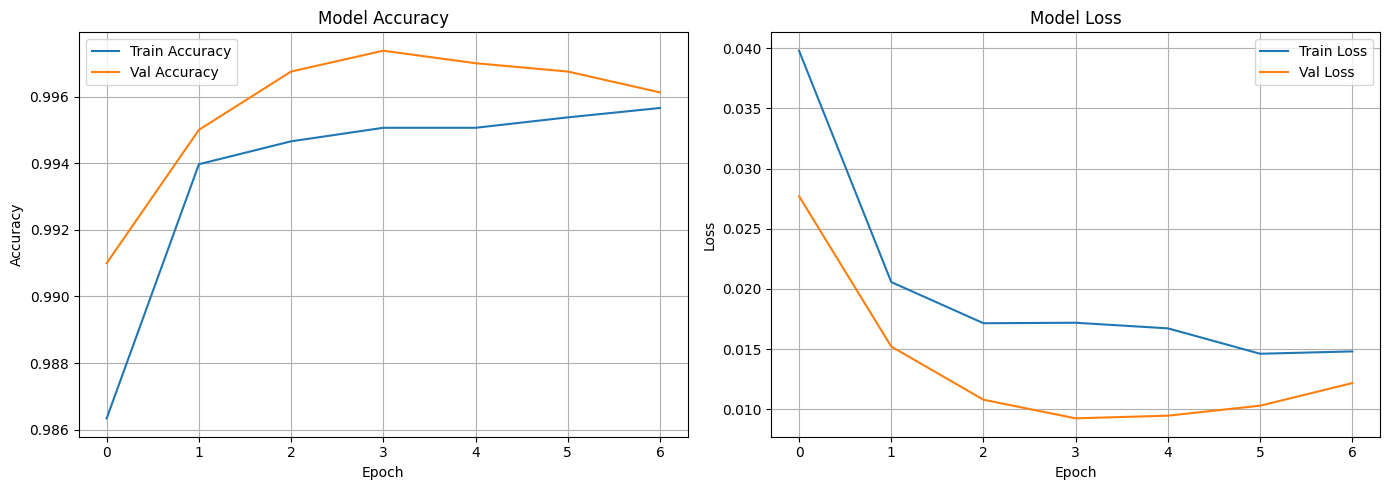

✓ Training history saved to ./backend/training_history.png


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('./backend/training_history.png', dpi=100)
plt.show()

print(f"✓ Training history saved to ./backend/training_history.png")

## Step 9: Summary

In [11]:
print(f"\n" + "="*60)
print("TRAINING COMPLETE")
print("="*60)
print(f"\nModel saved to: {MODEL_SAVE_PATH}")
print(f"\nFinal Metrics:")
print(f"  Train Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"  Val Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"  Train Loss: {history.history['loss'][-1]:.4f}")
print(f"  Val Loss: {history.history['val_loss'][-1]:.4f}")
print(f"\nTotal Epochs: {len(history.history['loss'])}")
print("="*60)


TRAINING COMPLETE

Model saved to: ./backend/saved_models/damage_detector.h5

Final Metrics:
  Train Accuracy: 0.9957
  Val Accuracy: 0.9961
  Train Loss: 0.0148
  Val Loss: 0.0122

Total Epochs: 7


## Step 10: Cleanup (Optional)

In [12]:
# Uncomment to delete temp training data
# shutil.rmtree(TEMP_DIR)
# print(f"✓ Cleaned up {TEMP_DIR}")

print("Done! The model is ready for inference.")

Done! The model is ready for inference.
